In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [27]:
df_all = pd.read_csv('/Users/gregorko/Documents/Symbol_Info_extended.csv')

required = [
    "symbol",
    "company_name",
    "sector",
    "industry",
    "country",
    "market_cap",
    "return_on_assets",
    "return_on_equity",
    "profit_margins",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow"
]

df_all = df_all[required].copy()
df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all = df_all[df_all["market_cap"] > 0].copy()

df_all["pe_trailing"] = df_all["pe_trailing"].where(df_all["pe_trailing"] > 0)
df_all["price_to_book"] = df_all["price_to_book"].where(df_all["price_to_book"] > 0)

df = df_all[(df_all["country"] == "Brazil") | (df_all["country"] == "Mexico") | (df_all["country"] == "Cayman Islands")| (df_all["country"] == "Bermuda")]

print(len(df_all), len(df))


2970 57


In [92]:
display(df.loc[df["symbol"] == "EG", ["symbol", "company_name", "industry", "country", "market_cap"]])

df_A = df_all[df_all["industry"] == "Insurance - Reinsurance"].sort_values("market_cap", ascending=False).head(10).copy()

df_B = df.sort_values("market_cap", ascending=False).head(10).copy()

m_cap_eg = int(df.loc[df["symbol"] == "EG", "market_cap"].iloc[0])

df_all["df_diff_eg"] = abs(df_all["market_cap"] - m_cap_eg)

df_C = df_all.sort_values("df_diff_eg", ascending=True).head(11).copy()
df_C = df_C[df_C["df_diff_eg"] > 0]

if "EG" not in df_B["symbol"].values:
    eg_row = df[df["symbol"] == "EG"]
    df_B = pd.concat([df_B, eg_row])

display(df_A)
display(df_B)
display(df_C)

,symbol,company_name,industry,country,market_cap
894,EG,"Everest Group, Ltd.",Insurance - Reinsurance,Bermuda,1.395730e+10


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,df_diff_eg
2313,RGA,"Reinsurance Group of America, Incorporated",Financial Services,Insurance - Reinsurance,United States,1.402244e+10,0.00854,0.09905,0.04917,11.626289,1.054732,0.235,45.614,4.816500e+09,6.513766e+07
894,EG,"Everest Group, Ltd.",Financial Services,Insurance - Reinsurance,Bermuda,1.395730e+10,0.02655,0.13822,0.11732,7.183503,0.918047,-0.047,23.471,3.993250e+09,0.000000e+00
2350,RNR,RenaissanceRe Holdings Ltd.,Financial Services,Insurance - Reinsurance,Bermuda,1.260062e+10,0.05559,0.23367,0.24213,4.982468,1.179956,-0.366,12.571,2.523299e+09,1.356678e+09
1286,HG,"Hamilton Insurance Group, Ltd.",Financial Services,Insurance - Reinsurance,Bermuda,3.131527e+09,0.06028,0.33740,0.21742,5.180624,1.107095,-0.022,5.440,5.278266e+08,1.082577e+10
2557,SPNT,SiriusPoint Ltd.,Financial Services,Insurance - Reinsurance,Bermuda,2.741082e+09,0.02384,0.23113,0.16508,5.874055,1.174279,0.065,30.516,4.672250e+08,1.121622e+10
1192,GLRE,"Greenlight Capital Re, Ltd.",Financial Services,Insurance - Reinsurance,Cayman Islands,5.701313e+08,0.02470,0.11499,0.11452,7.283899,0.781257,-0.069,1.041,2.756268e+08,1.338717e+10


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2102,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Energy,Oil & Gas Integrated,Brazil,1.213202e+11,0.08231,0.25601,0.21599,5.469136,1.369260,0.004,83.269,8.293275e+10
1466,ITUB,Itaú Unibanco Holding S.A.,Financial Services,Banks - Regional,Brazil,8.618888e+10,0.01574,0.21816,0.33278,9.536586,2.063238,-0.021,NaN,NaN
167,AMX,"América Móvil, S.A.B. de C.V.",Communication Services,Telecom Services,Mexico,7.858860e+10,0.06641,0.21128,0.09227,15.652695,3.679852,0.021,170.868,1.402851e+11
2859,VALE,Vale S.A.,Basic Materials,Other Industrial Metals & Mining,Brazil,7.025672e+10,0.08187,0.06839,0.07262,24.969696,1.909549,0.027,57.146,1.060013e+10
1959,NU,Nu Holdings Ltd.,Financial Services,Banks - Regional,Brazil,6.188996e+10,0.04840,0.30055,0.41924,19.584616,5.475268,0.437,NaN,NaN
12,ABEV,Ambev S.A.,Consumer Defensive,Beverages - Brewers,Brazil,4.983262e+10,0.09784,0.17251,0.17660,16.000000,2.776781,-0.001,3.420,1.820394e+10
691,CRDO,Credo Technology Group Holding Ltd,Technology,Semiconductors,Cayman Islands,4.028571e+10,0.14680,0.27544,0.31809,120.668510,21.762653,2.015,0.880,1.722411e+08
2877,VIK,Viking Holdings Ltd,Consumer Cyclical,Travel Services,Bermuda,3.757982e+10,0.07963,3.00090,0.18003,31.312267,34.323555,0.175,546.395,5.431819e+08
323,BBD,Banco Bradesco S.A.,Financial Services,Banks - Regional,Brazil,3.668037e+10,0.01046,0.13366,0.25358,8.261905,1.032714,0.105,NaN,NaN
25,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda,3.364622e+10,0.04568,0.21306,0.24635,7.407692,1.449123,-0.033,11.282,5.276125e+09


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,df_diff_eg
570,CHKP,Check Point Software Technologies Ltd.,Technology,Software - Infrastructure,Israel,1.390124e+10,0.07789,0.38024,0.38374,13.747943,4.971355,0.048,70.124,7.302875e+08,56062976.0
2313,RGA,"Reinsurance Group of America, Incorporated",Financial Services,Insurance - Reinsurance,United States,1.402244e+10,0.00854,0.09905,0.04917,11.626289,1.054732,0.235,45.614,4.816500e+09,65137664.0
268,AUR,"Aurora Innovation, Inc.",Consumer Cyclical,Auto Parts,United States,1.386571e+10,-0.27432,-0.44332,0.00000,NaN,7.041833,NaN,4.022,-4.017500e+08,91592704.0
710,CSGP,"CoStar Group, Inc.",Real Estate,Real Estate Services,United States,1.386368e+10,-0.00158,0.00303,0.00733,485.000000,1.746669,0.225,14.526,2.022000e+08,93622272.0
2462,SGI,Somnigroup International Inc.,Consumer Cyclical,"Furnishings, Fixtures & Appliances",United States,1.406968e+10,0.05557,0.17678,0.06795,26.756000,4.469464,0.123,207.096,6.377500e+08,112385024.0
2799,UDR,"UDR, Inc.",Real Estate,REIT - Residential,United States,1.408330e+10,0.02214,0.12350,0.27782,25.857141,3.820100,0.042,142.368,1.007130e+09,126000128.0
1982,NWSA,News Corporation,Communication Services,Entertainment,United States,1.413548e+10,0.04113,0.06524,0.12920,32.772152,1.659509,0.088,31.559,1.744000e+09,178178048.0
1344,HTHT,H World Group Limited,Consumer Cyclical,Lodging,China,1.377399e+10,0.07184,0.46356,0.19311,19.306036,8.549539,0.111,322.124,6.473750e+09,183307264.0
538,CDW,CDW Corporation,Technology,Information Technology Services,United States,1.415764e+10,0.06698,0.44157,0.04703,13.498173,5.550992,0.092,240.522,8.841000e+08,200337408.0
1800,MOD,Modine Manufacturing Company,Consumer Cyclical,Auto Parts,United States,1.373753e+10,0.09892,0.10015,0.03403,143.142850,12.262073,0.305,66.658,-1.095750e+08,219768832.0


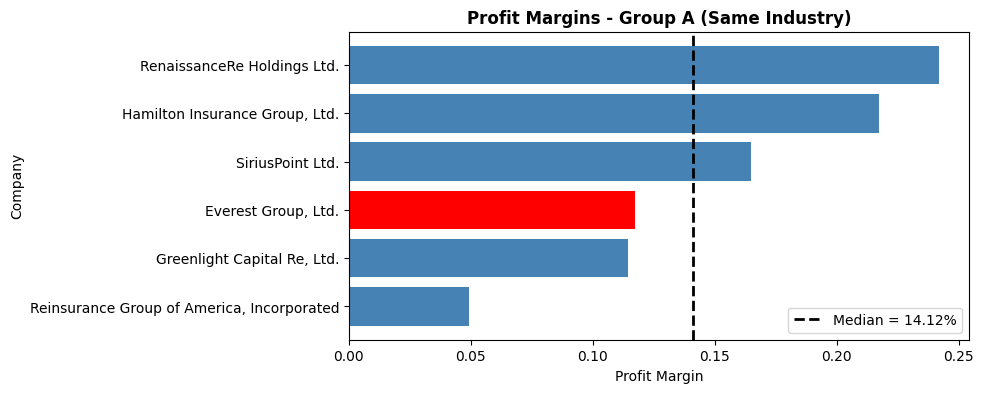

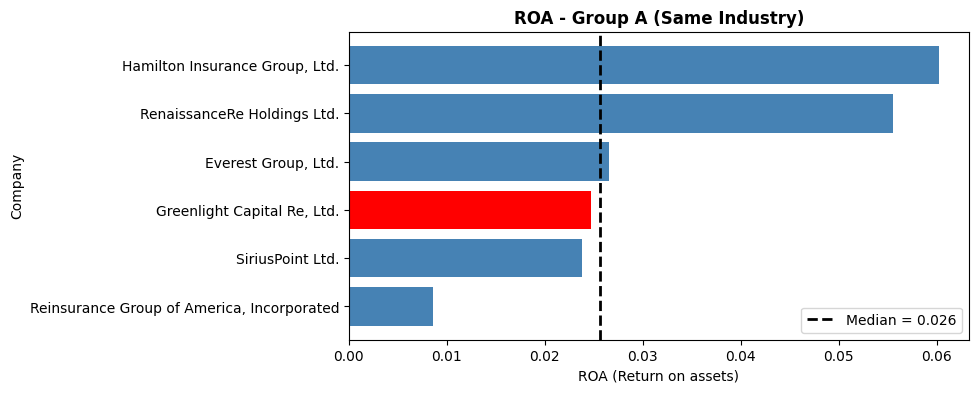

In [95]:


df_A = df_A.sort_values("profit_margins", ascending=True).head(10)

colors = [
    "red" if name == "Everest Group, Ltd." else "steelblue"
    for name in df_A["company_name"]
]

plt.figure(figsize=(8,4))

plt.barh(
    df_A["company_name"],
    df_A["profit_margins"],
    color=colors
)

median_profit_A = df_A["profit_margins"].median()

plt.axvline(
    median_profit_A,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_profit_A:.2%}"
)

plt.xlabel("Profit Margin")
plt.ylabel("Company")
plt.title("Profit Margins - Group A (Same Industry)")
plt.legend()

plt.show()

#graf_2_A

df_A = df_A.sort_values("return_on_assets", ascending=True).head(10)

plt.figure(figsize=(8,4))

plt.barh(
    df_A["company_name"],
    df_A["return_on_assets"],
    color=colors
)

median_roa_A = df_A["return_on_assets"].median()

plt.axvline(
    median_roa_A,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_roa_A:.2}"
)

plt.xlabel("ROA (Return on assets)")
plt.ylabel("Company")
plt.title("ROA - Group A (Same Industry)")
plt.legend()

plt.show()

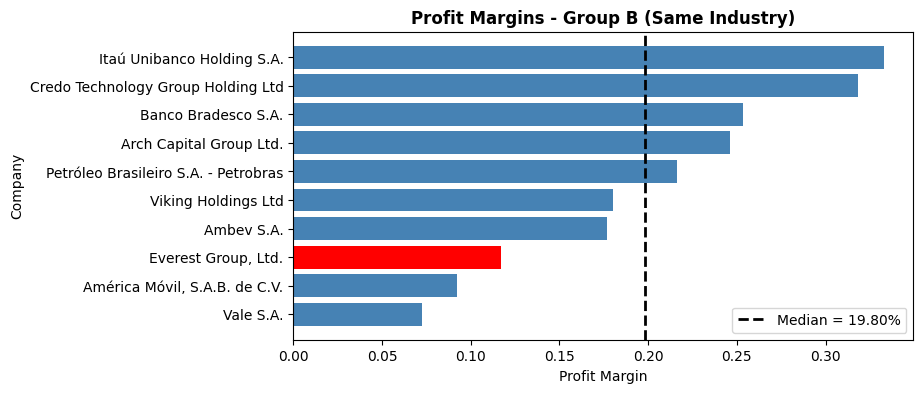

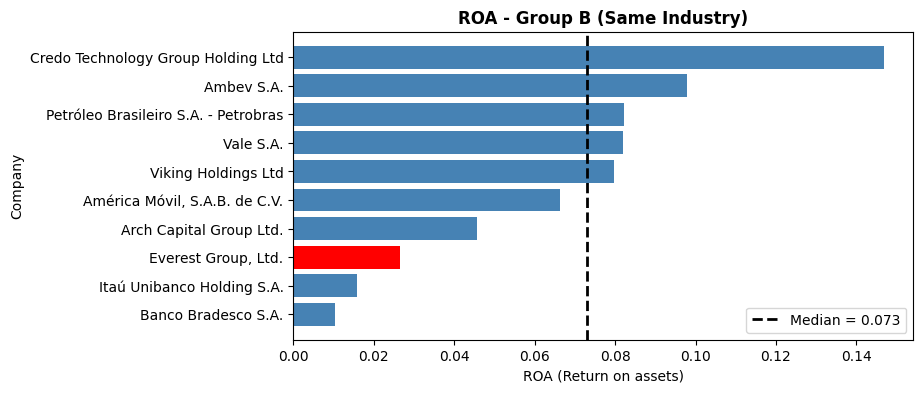

In [97]:
df_B = df_B.sort_values("profit_margins", ascending=True).head(10)

colors = [
    "red" if name == "Everest Group, Ltd." else "steelblue"
    for name in df_B["company_name"]
]

plt.figure(figsize=(8,4))

plt.barh(
    df_B["company_name"],
    df_B["profit_margins"],
    color=colors
)

median_profit_B = df_B["profit_margins"].median()

plt.axvline(
    median_profit_B,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_profit_B:.2%}"
)

plt.xlabel("Profit Margin")
plt.ylabel("Company")
plt.title("Profit Margins - Group B (Same Industry)")
plt.legend()

plt.show()

#graf_2_B

df_B = df_B.sort_values("return_on_assets", ascending=True).head(10)

plt.figure(figsize=(8,4))

plt.barh(
    df_B["company_name"],
    df_B["return_on_assets"],
    color=colors
)

median_roa_B = df_B["return_on_assets"].median()

plt.axvline(
    median_roa_B,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_roa_B:.2}"
)

plt.xlabel("ROA (Return on assets)")
plt.ylabel("Company")
plt.title("ROA - Group B (Same Industry)")
plt.legend()

plt.show()

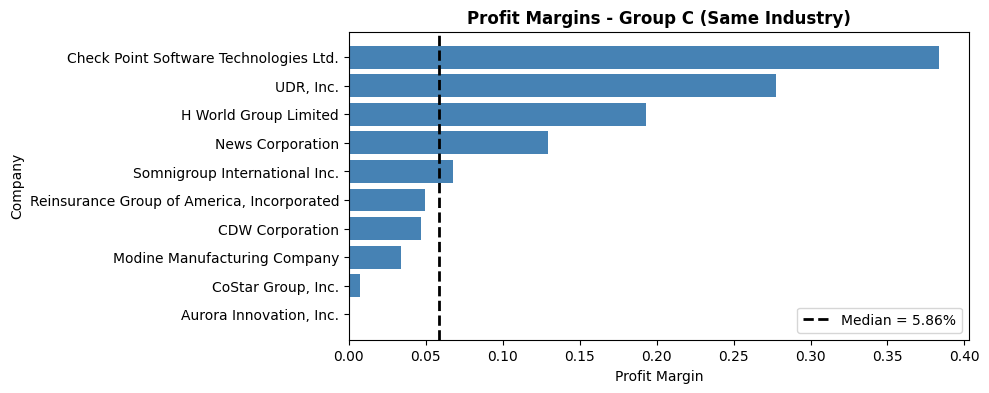

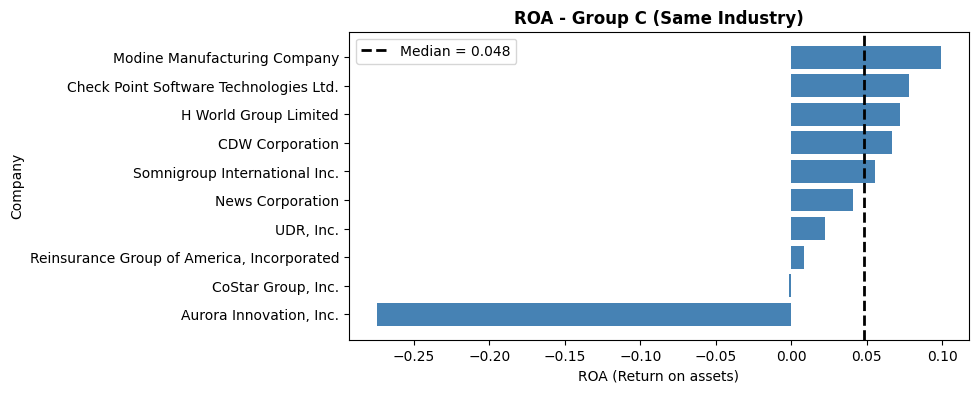

In [99]:
df_C = df_C.sort_values("profit_margins", ascending=True).head(10)

colors = [
    "red" if name == "Everest Group, Ltd." else "steelblue"
    for name in df_C["company_name"]
]

plt.figure(figsize=(8,4))

plt.barh(
    df_C["company_name"],
    df_C["profit_margins"],
    color=colors
)

median_profit_C = df_C["profit_margins"].median()

plt.axvline(
    median_profit_C,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_profit_C:.2%}"
)

plt.xlabel("Profit Margin")
plt.ylabel("Company")
plt.title("Profit Margins - Group C (Same Industry)")
plt.legend()

plt.show()

#graf_2_C

df_C = df_C.sort_values("return_on_assets", ascending=True).head(10)

plt.figure(figsize=(8,4))

plt.barh(
    df_C["company_name"],
    df_C["return_on_assets"],
    color=colors
)

median_roa_C = df_C["return_on_assets"].median()

plt.axvline(
    median_roa_C,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_roa_C:.2}"
)

plt.xlabel("ROA (Return on assets)")
plt.ylabel("Company")
plt.title("ROA - Group C (Same Industry)")
plt.legend()

plt.show()